In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load dataset

In [2]:
df = pd.read_csv("DataSet_2000.csv")

## ===== BASIC INFO =====

In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         2000 non-null   object 
 1   product_rating        1998 non-null   float64
 2   total_reviews         1998 non-null   float64
 3   purchased_last_month  1700 non-null   float64
 4   discounted_price      1921 non-null   float64
 5   original_price        1921 non-null   float64
 6   is_best_seller        2000 non-null   object 
 7   is_sponsored          2000 non-null   object 
 8   has_coupon            2000 non-null   object 
 9   buy_box_availability  1403 non-null   object 
 10  delivery_date         1463 non-null   object 
 11  sustainability_tags   336 non-null    object 
 12  product_image_url     2000 non-null   object 
 13  product_page_url      1852 non-null   object 
 14  data_collected_at     2000 non-null   object 
 15  product_category     

## ===== TOP PRODUCTS (Best Value) =====

## Create score: rating * reviews

In [4]:
df['value_score'] = df['product_rating'] * df['total_reviews']

top_products = df.sort_values(by='value_score', ascending=False).head(10)
print("\nTop 10 Best Value Products:")
print(top_products[['product_title', 'product_rating', 'total_reviews']])


Top 10 Best Value Products:
                                         product_title  product_rating  \
10   Amazon Basics 48-Pack AA Alkaline High-Perform...             4.7   
17   Amazon Basics AAA Alkaline High-Performance Ba...             4.7   
695  Amazon Basics HDMI Cable, 3ft, 4K@60Hz, High-S...             4.7   
750  Blink Mini - Compact indoor plug-in smart secu...             4.4   
54   Seagate Portable 2TB External Hard Drive HDD —...             4.6   
62   Amazon Basics 8-Pack 9V Alkaline Batteries, 5-...             4.7   
120  Amazon Basics Dog and Puppy Pee Pads with 5-La...             4.5   
158  SanDisk 256GB Ultra microSDXC UHS-I Memory Car...             4.7   
16   Amazon Basics Multipurpose Copy Printer Paper,...             4.8   
736  Amazon Basics 12-Pack Rechargeable AAA NiMH Pe...             4.6   

     total_reviews  
10        865598.0  
17        625776.0  
695       553927.0  
750       302790.0  
54        262557.0  
62        231583.0  
120      

## ===== GRAPH 1: Rating Distribution =====

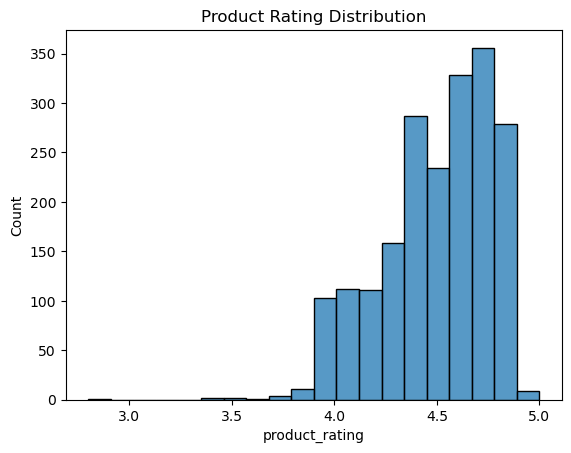

In [5]:
plt.figure()
sns.histplot(df['product_rating'], bins=20)
plt.title("Product Rating Distribution")
plt.savefig("rating.png")
plt.show()


## ===== GRAPH 2: Price vs Discount =====

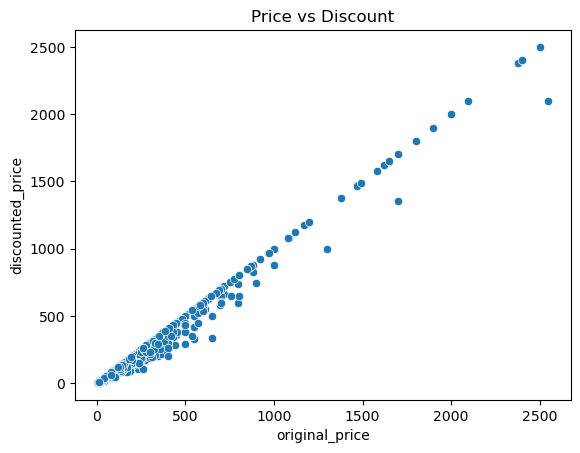

In [6]:
plt.figure()
sns.scatterplot(x='original_price', y='discounted_price', data=df)
plt.title("Price vs Discount")
plt.savefig("price.png")
plt.show()

## ===== GRAPH 3: Reviews vs Rating =====

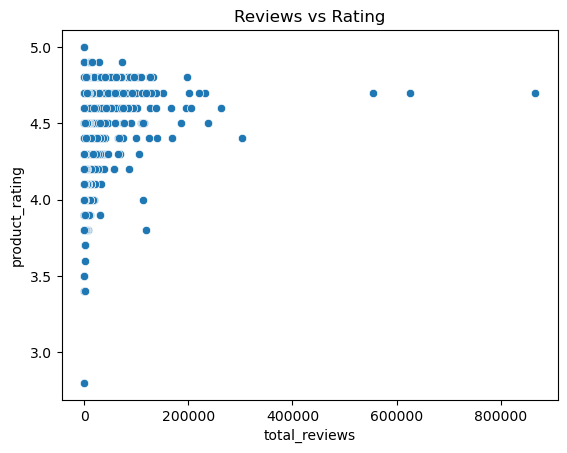

In [8]:
plt.figure()
sns.scatterplot(x='total_reviews', y='product_rating', data=df)
plt.title("Reviews vs Rating")
plt.savefig("reviews.png")
plt.show()

## ===== GRAPH 4: Best Seller Analysis =====

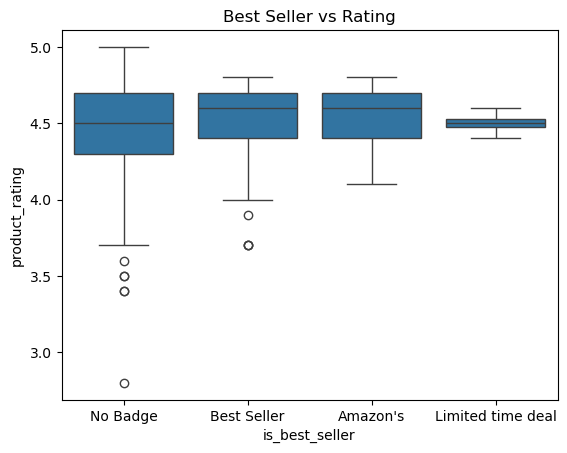

In [9]:
plt.figure()
sns.boxplot(x='is_best_seller', y='product_rating', data=df)
plt.title("Best Seller vs Rating")
plt.savefig("bestseller.png")
plt.show()

## ===== GRAPH 5: Category Distribution =====

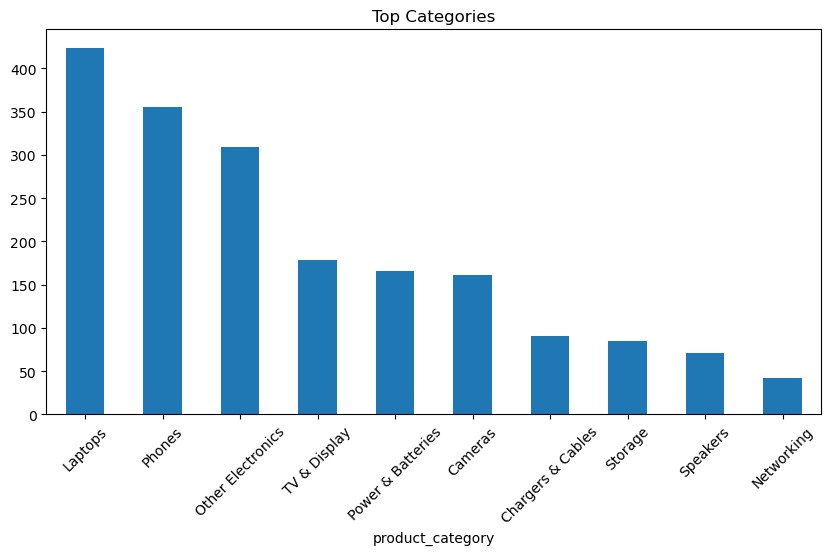

In [11]:
plt.figure(figsize=(10,5))
df['product_category'].value_counts().head(10).plot(kind='bar')
plt.title("Top Categories")
plt.xticks(rotation=45)
plt.savefig("category.png")
plt.show()


## ===== 6. HEATMAP =====

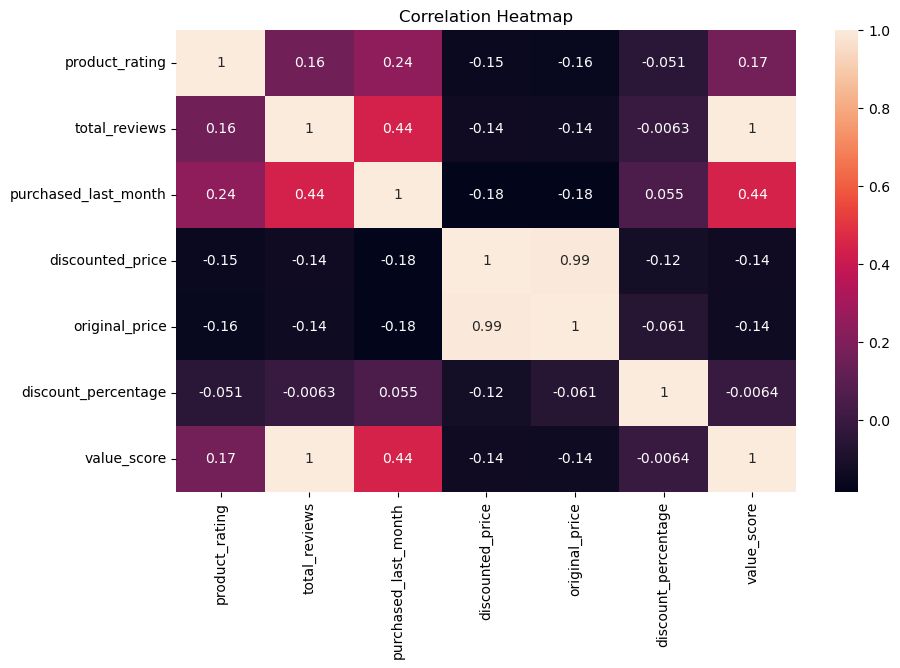

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.savefig("heatmap.png")
plt.show()

## Top 10 Highest Rated Products

In [13]:
top_rated = df.sort_values(by='product_rating', ascending=False).head(10)

print("Top 10 Highest Rated Products:")
print(top_rated[['product_title', 'product_rating']])

Top 10 Highest Rated Products:
                                          product_title  product_rating
1238  Poly Studio V12 – USB Video Bar for Small Room...             5.0
697   Legrand Wiremold RDSZCBK radiant Furniture Pow...             4.9
44    Scotch Thermal Laminating Pouches, for Use wit...             4.9
137   Scotch Thermal Laminating Pouches, 200 Count, ...             4.9
194   Scotch Thermal Laminating Pouches, 100 Count, ...             4.9
1846  Melissa & Doug Stainless Steel Pots and Pans P...             4.9
353   Legrand Wiremold RDSZCBK radiant Furniture Pow...             4.9
1560  Melissa & Doug Pizza Party Wooden Play Food Se...             4.9
532   Legrand Wiremold RDSZCBK radiant Furniture Pow...             4.9
449   Duracell Coppertop 9V Battery, 6 Count (Pack o...             4.8


In [14]:
## “Top rated products have ratings close to 5.”

##  Most Reviewed Products

In [15]:
top_reviews = df.sort_values(by='total_reviews', ascending=False).head(10)

print("Top 10 Most Reviewed Products:")
print(top_reviews[['product_title', 'total_reviews']])

Top 10 Most Reviewed Products:
                                          product_title  total_reviews
10    Amazon Basics 48-Pack AA Alkaline High-Perform...       865598.0
17    Amazon Basics AAA Alkaline High-Performance Ba...       625776.0
695   Amazon Basics HDMI Cable, 3ft, 4K@60Hz, High-S...       553927.0
750   Blink Mini - Compact indoor plug-in smart secu...       302790.0
54    Seagate Portable 2TB External Hard Drive HDD —...       262557.0
120   Amazon Basics Dog and Puppy Pee Pads with 5-La...       237579.0
62    Amazon Basics 8-Pack 9V Alkaline Batteries, 5-...       231583.0
158   SanDisk 256GB Ultra microSDXC UHS-I Memory Car...       219712.0
736   Amazon Basics 12-Pack Rechargeable AAA NiMH Pe...       205678.0
1589                                       Apple AirTag       201087.0


In [16]:
## Highly reviewed products indicate customer trust

## .Average Price Analysis

In [17]:
avg_price = df['discounted_price'].mean()
print("Average Discounted Price:", avg_price)

Average Discounted Price: 136.57858407079644


In [18]:
## Average product price helps understand market range.

## Best Seller Count

In [19]:
print(df['is_best_seller'].value_counts())

is_best_seller
No Badge             1806
Best Seller           146
Amazon's               44
Limited time deal       4
Name: count, dtype: int64


In [20]:
## print(df['is_best_seller'].value_counts())

## 7.Coupon Impact

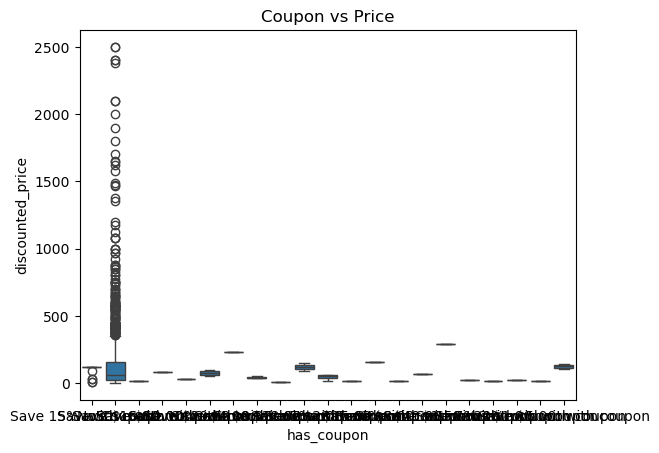

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='has_coupon', y='discounted_price', data=df)
plt.title("Coupon vs Price")
plt.savefig("coupon.png")
plt.show()

##  8.Discount Percentage Histogram

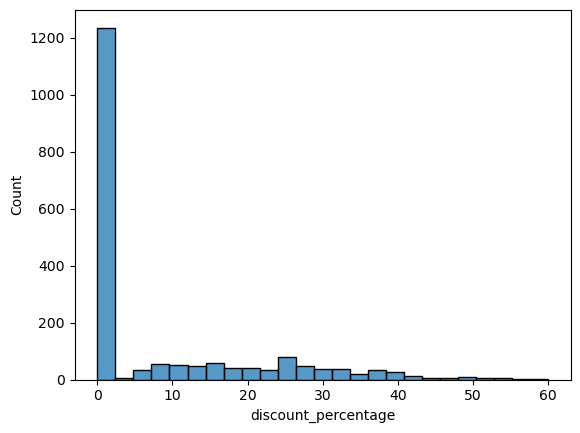

In [23]:
plt.figure()
sns.histplot(df['discount_percentage'])
plt.savefig("g1_discount_hist.png")
plt.show()

### Interpretation: 
The histogram shows the distribution of discount percentages across products. It can be observed that most products fall within a moderate discount range, indicating that extreme discounts are less common. This suggests that sellers generally maintain balanced pricing strategies to attract customers while ensuring profitability.

## 9. Total Reviews Histogram

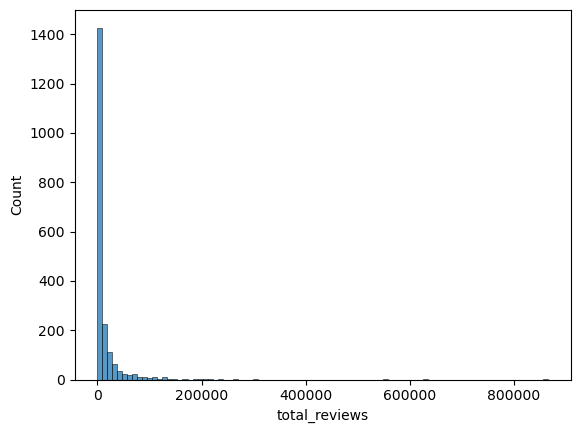

In [31]:
plt.figure()
sns.histplot(df['total_reviews'])
plt.savefig("g2_reviews_hist.png")
plt.show()

## 10. Original Price Histogram

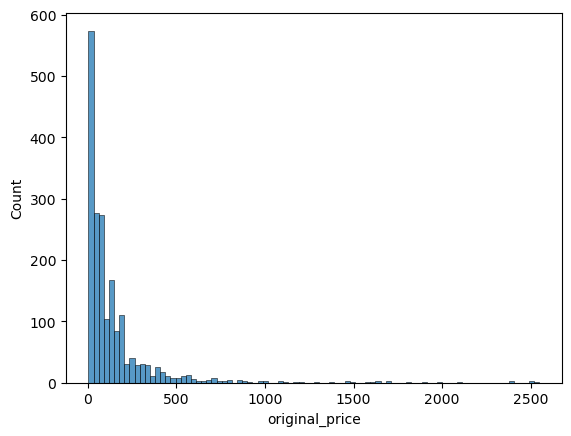

In [32]:
plt.figure()
sns.histplot(df['original_price'])
plt.savefig("g3_original_price.png")
plt.show()

### Interpretation:
The distribution of original prices shows that most products are concentrated in a lower to mid price range. High-priced products are fewer in number, indicating that the marketplace is dominated by affordable products catering to a wider audience.

## 11. Discount vs Rating

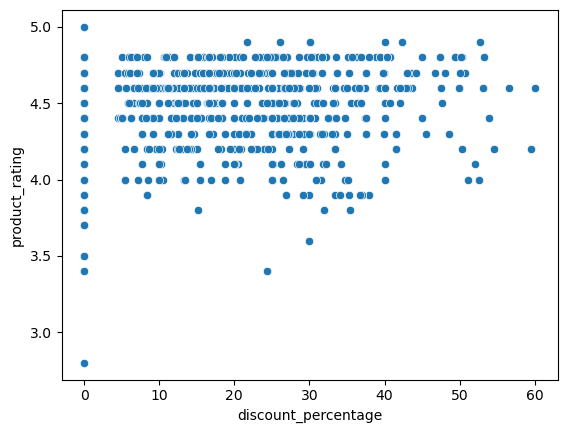

In [33]:
plt.figure()
sns.scatterplot(x='discount_percentage', y='product_rating', data=df)
plt.savefig("g4_discount_rating.png")
plt.show()

### Interpretation:
This scatter plot shows the relationship between discount percentage and product rating. The data suggests that higher discounts do not necessarily guarantee better ratings. Ratings appear to be influenced more by product quality rather than pricing strategies.

## 12. Discount vs Reviews

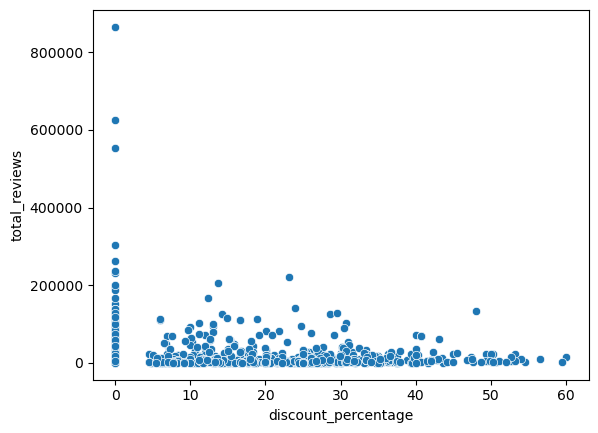

In [34]:
plt.figure()
sns.scatterplot(x='discount_percentage', y='total_reviews', data=df)
plt.savefig("g5_discount_reviews.png")
plt.show()

### Interpretation:
The graph indicates the relationship between discounts and number of reviews. While some discounted products receive higher reviews, there is no strong consistent pattern. This suggests that discounts may attract customers, but reviews depend on overall customer satisfaction.

## 13. Rating Boxplot

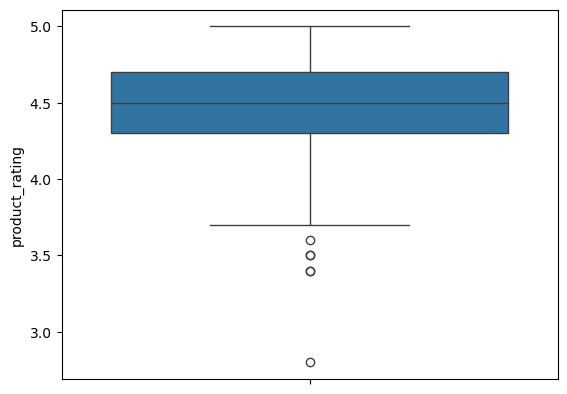

In [36]:
plt.figure()
sns.boxplot(y=df['product_rating'])
plt.savefig("g6_rating_box.png")
plt.show()

### Interpretation:
The boxplot highlights the spread and variation of product ratings. Most ratings are concentrated within a narrow range, indicating consistency in product quality. Few outliers exist, representing products with unusually low or high ratings.

## 14. Reviews Boxplot

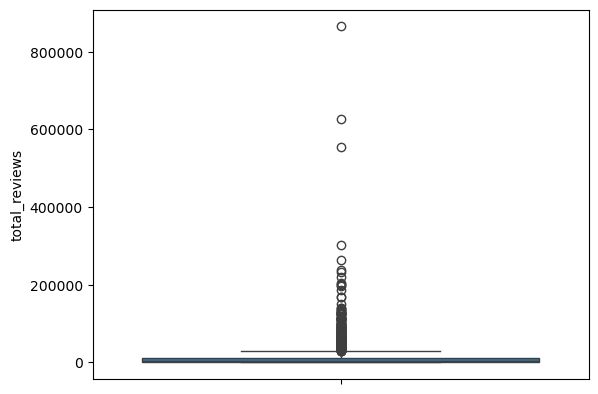

In [37]:
plt.figure()
sns.boxplot(y=df['total_reviews'])
plt.savefig("g7_reviews_box.png")
plt.show()

### Interpretation:
This boxplot shows that the number of reviews varies significantly across products. A few products have extremely high review counts, while most have relatively low engagement, indicating unequal popularity distribution.

## 15. Price Boxplot

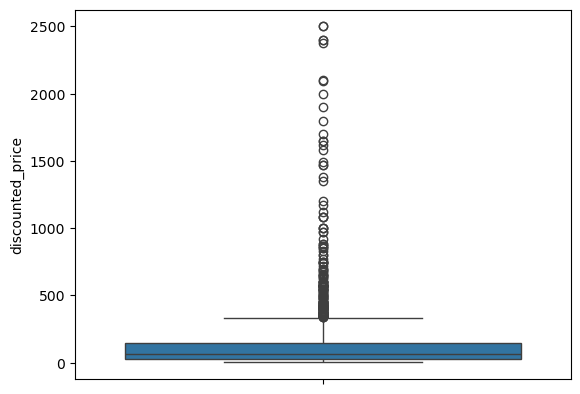

In [38]:
plt.figure()
sns.boxplot(y=df['discounted_price'])
plt.savefig("g8_price_box.png")
plt.show()

### Interpretation:
The price distribution indicates that most products are clustered within a moderate price range, with some high-priced outliers. This reflects a diverse pricing strategy within the marketplace.

 ## 16. Best Seller Count.

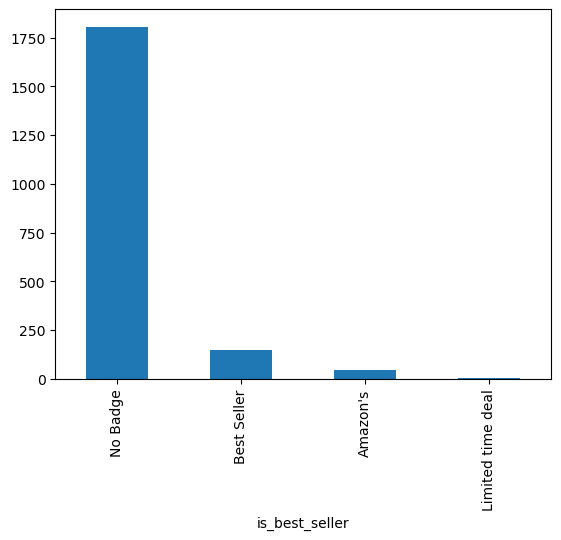

In [39]:
plt.figure()
df['is_best_seller'].value_counts().plot(kind='bar')
plt.savefig("g9_bestseller_count.png")
plt.show()

### Interpretation:
The bar chart shows the count of best seller vs non-best seller products. It is evident that only a small portion of products achieve best seller status, highlighting the competitive nature of the marketplace

## 17. Sponsored Products Count

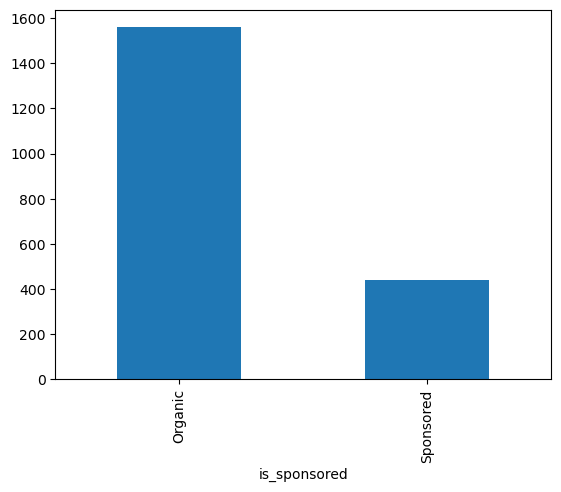

In [40]:
plt.figure()
df['is_sponsored'].value_counts().plot(kind='bar')
plt.savefig("g10_sponsored.png")
plt.show()

### Interpretation:
This graph shows the distribution of sponsored and non-sponsored products. Most products are not sponsored, suggesting that only a limited number of sellers invest in promotional strategies.

## 18. Coupon Count

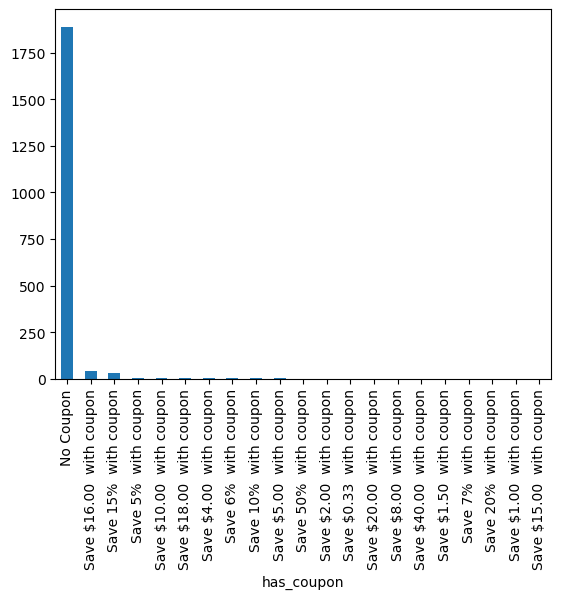

In [41]:
plt.figure()
df['has_coupon'].value_counts().plot(kind='bar')
plt.savefig("g11_coupon_count.png")
plt.show()

### Interpretation:
The bar chart illustrates the number of products offering coupons versus those without coupons. It is observed that fewer products provide coupon offers, indicating that promotional strategies like coupons are selectively used. This suggests that not all sellers rely on discounts to attract customers.

## 19. Rating vs Coupon

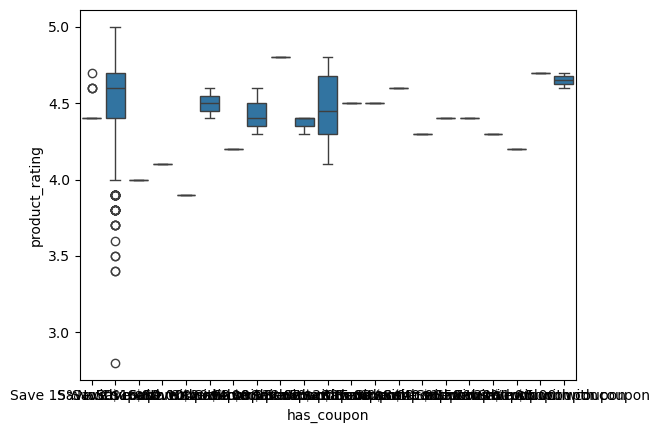

In [42]:
plt.figure()
sns.boxplot(x='has_coupon', y='product_rating', data=df)
plt.savefig("g12_coupon_rating.png")
plt.show()

### Interpretation:
This graph compares product ratings based on the availability of coupons. The results indicate that products with coupons do not always have significantly higher ratings. This shows that coupon availability does not directly influence product quality or customer satisfaction.

## 20. Rating vs Sponsored

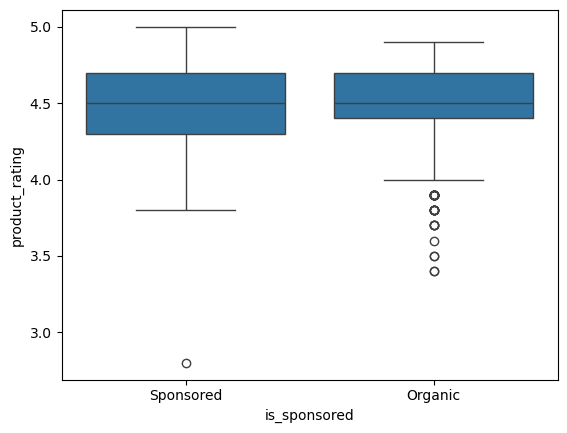

In [43]:
plt.figure()
sns.boxplot(x='is_sponsored', y='product_rating', data=df)
plt.savefig("g13_sponsored_rating.png")
plt.show()

### Interpretation:
The boxplot highlights the relationship between sponsorship and ratings. It shows that sponsored products do not necessarily have better ratings compared to non-sponsored ones, indicating that advertising does not guarantee higher product quality.

## 21. Price vs Reviews

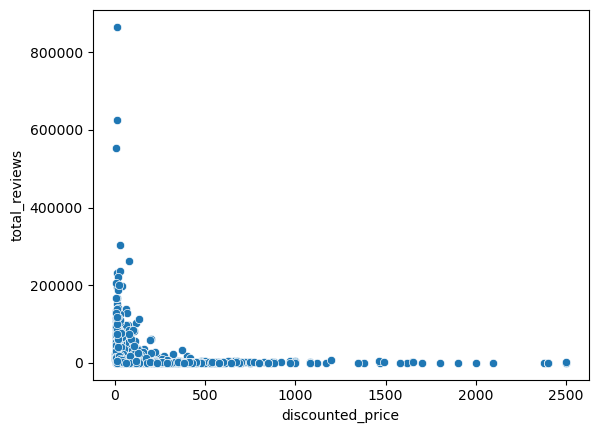

In [44]:
plt.figure()
sns.scatterplot(x='discounted_price', y='total_reviews', data=df)
plt.savefig("g14_price_reviews.png")
plt.show()

### Interpretation:
This scatter plot shows the relationship between price and customer reviews. It indicates that both low and high-priced products can receive a large number of reviews. Therefore, price alone does not determine product popularity.

## 22. Rating vs Price

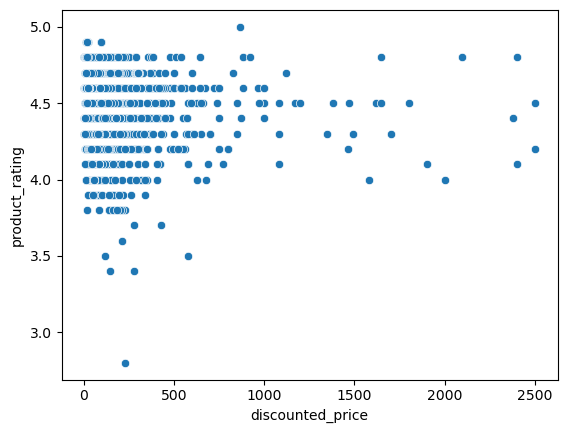

In [45]:
plt.figure()
sns.scatterplot(x='discounted_price', y='product_rating', data=df)
plt.savefig("g15_price_rating.png")
plt.show()

### Interpretation:
The graph demonstrates that there is no strong correlation between product price and rating. High-priced products do not always have higher ratings, suggesting that customer satisfaction depends on multiple factors beyond price.

## 23. Discount vs Price

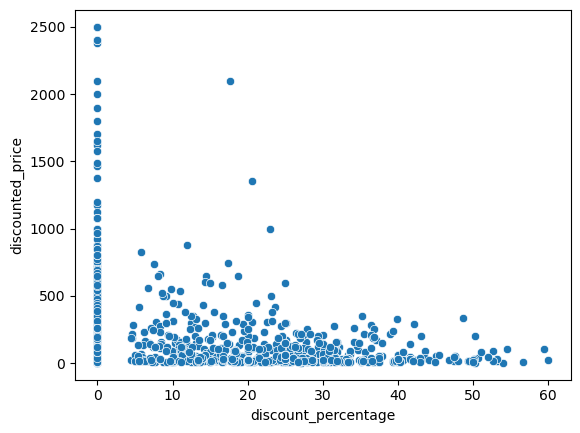

In [46]:
plt.figure()
sns.scatterplot(x='discount_percentage', y='discounted_price', data=df)
plt.savefig("g16_discount_price.png")
plt.show()

### Interpretation:
This plot shows how discounts relate to product pricing. It is observed that products with higher prices tend to offer larger discounts, which may be a strategy to attract customers and increase sales.

## 24. Category Pie Chart

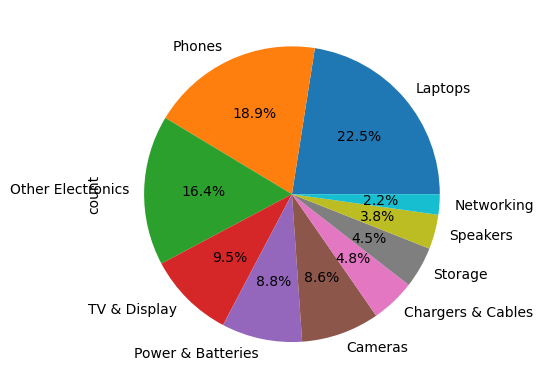

In [47]:
plt.figure()
df['product_category'].value_counts().head(10).plot(kind='pie', autopct='%1.1f%%')
plt.savefig("g17_category_pie.png")
plt.show()

### Interpretation:
The pie chart represents the proportion of top product categories. It shows that a few categories dominate the dataset, indicating that customer demand is concentrated in specific product types.

## 25. Reviews vs Discount (Line)

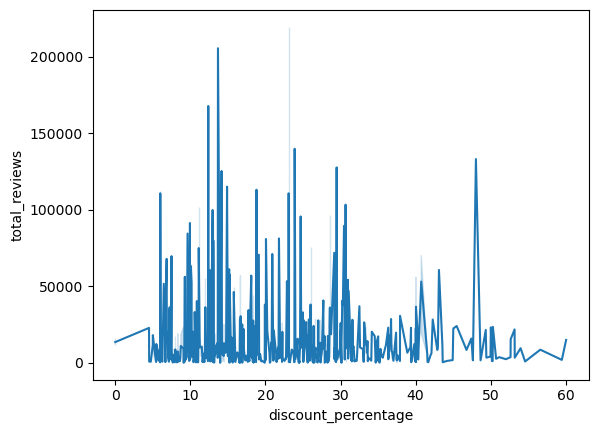

In [49]:
plt.figure()
sns.lineplot(x='discount_percentage', y='total_reviews', data=df)
plt.savefig("g18_line.png")
plt.show()

### Interpretation:
This line graph shows trends between discounts and reviews. While some variation is observed, there is no consistent upward or downward trend, indicating that discounts alone do not significantly affect customer engagement.

## 26. Rating KDE Plot

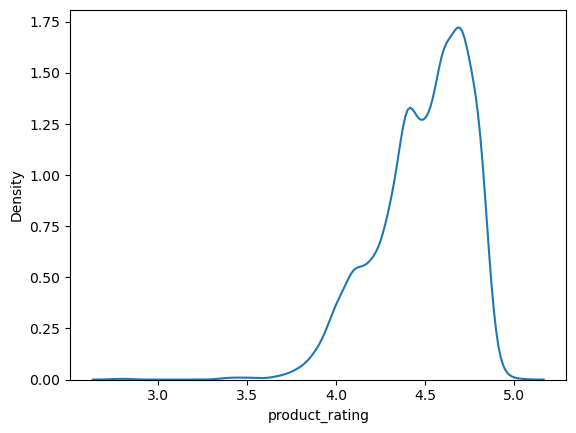

In [50]:
plt.figure()
sns.kdeplot(df['product_rating'])
plt.savefig("g19_kde.png")
plt.show()

### Interpretation:
The KDE plot shows the density distribution of product ratings. It highlights that most ratings are concentrated in the higher range, indicating generally positive customer feedback across products.

## 27. Price KDE Plot

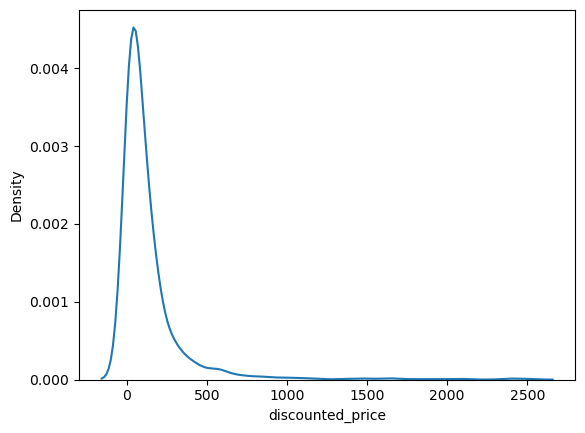

In [51]:
plt.figure()
sns.kdeplot(df['discounted_price'])
plt.savefig("g20_price_kde.png")
plt.show()

### Interpretation:
This graph shows the density distribution of product prices. It reveals that most products fall within a mid-range pricing category, with fewer products at extreme price points.

## 28. Reviews KDE Plot

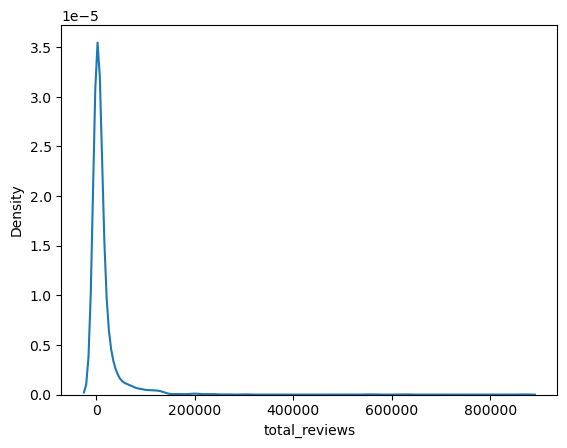

In [53]:
plt.figure()
sns.kdeplot(df['total_reviews'])
plt.savefig("g21_reviews_kde.png")
plt.show()

### Interpretation:
The KDE plot indicates that most products receive a low to moderate number of reviews, while only a few products achieve very high review counts, reflecting uneven customer engagement.

## 29. Category vs Rating

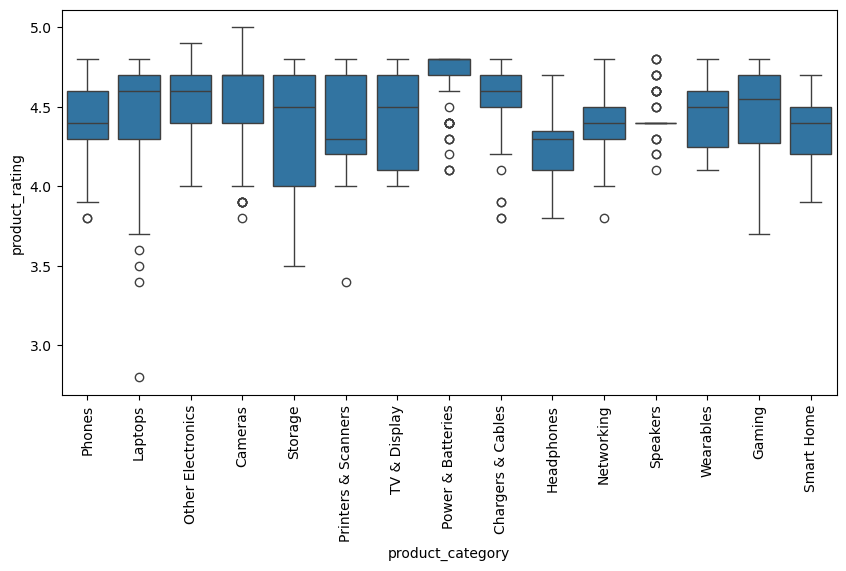

In [55]:
plt.figure(figsize=(10,5))
sns.boxplot(x='product_category', y='product_rating', data=df)
plt.xticks(rotation=90)
plt.savefig("g22_cat_rating.png")
plt.show()

### Interpretation:
This boxplot compares ratings across different categories. It shows that some categories consistently receive higher ratings, suggesting better product quality or customer satisfaction in those segments.

## 30. Category vs Price

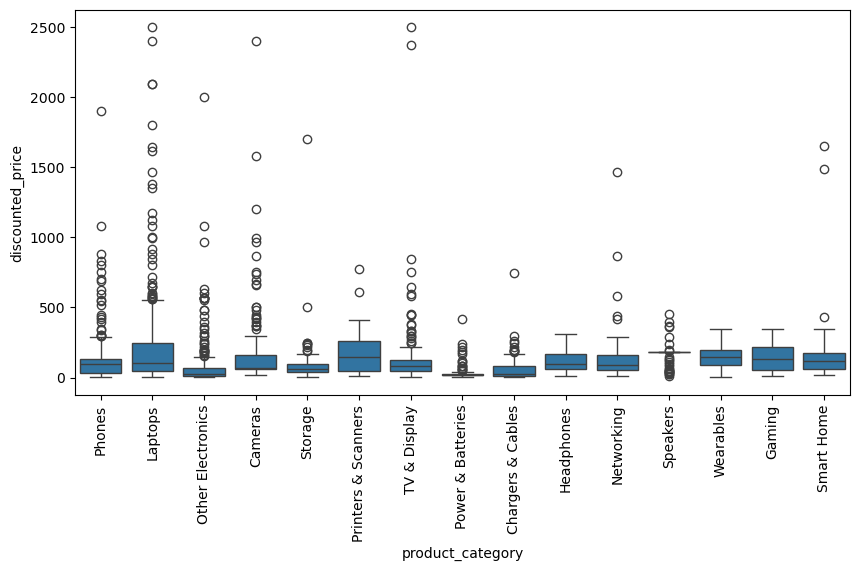

In [57]:
plt.figure(figsize=(10,5))
sns.boxplot(x='product_category', y='discounted_price', data=df)
plt.xticks(rotation=90)
plt.savefig("g23_cat_price.png")
plt.show()

### Interpretation:
The graph shows variation in pricing across categories. Some categories have significantly higher price ranges, indicating differences in product value and market positioning.

## 31. Heatmap (Alternate)

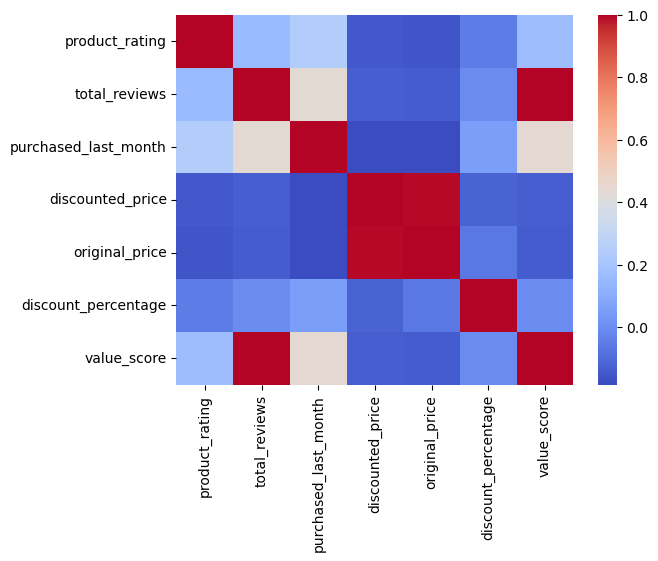

In [58]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.savefig("g24_heatmap2.png")
plt.show()

### Interpretation:
The heatmap visualizes correlations between numerical variables. It helps identify strong relationships, such as between price-related features, which can be useful for deeper analysis.

## 32. Reviews Log Scale

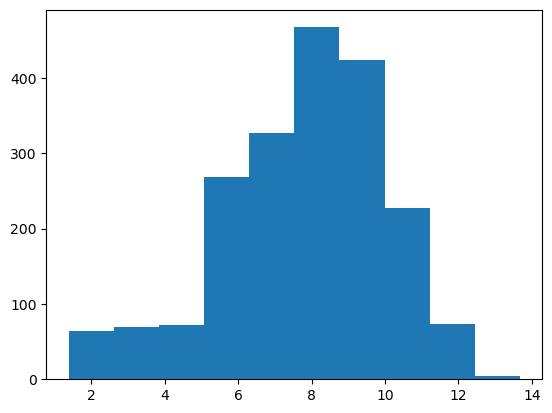

In [59]:
import numpy as np

plt.figure()
plt.hist(np.log1p(df['total_reviews']))
plt.savefig("g25_log_reviews.png")
plt.show()

### Interpretation:
The log-transformed histogram of reviews helps normalize skewed data. It reveals patterns more clearly by reducing the effect of extreme values, making the distribution easier to interpret.

## 33. Pairplot (Multiple relationships in one)

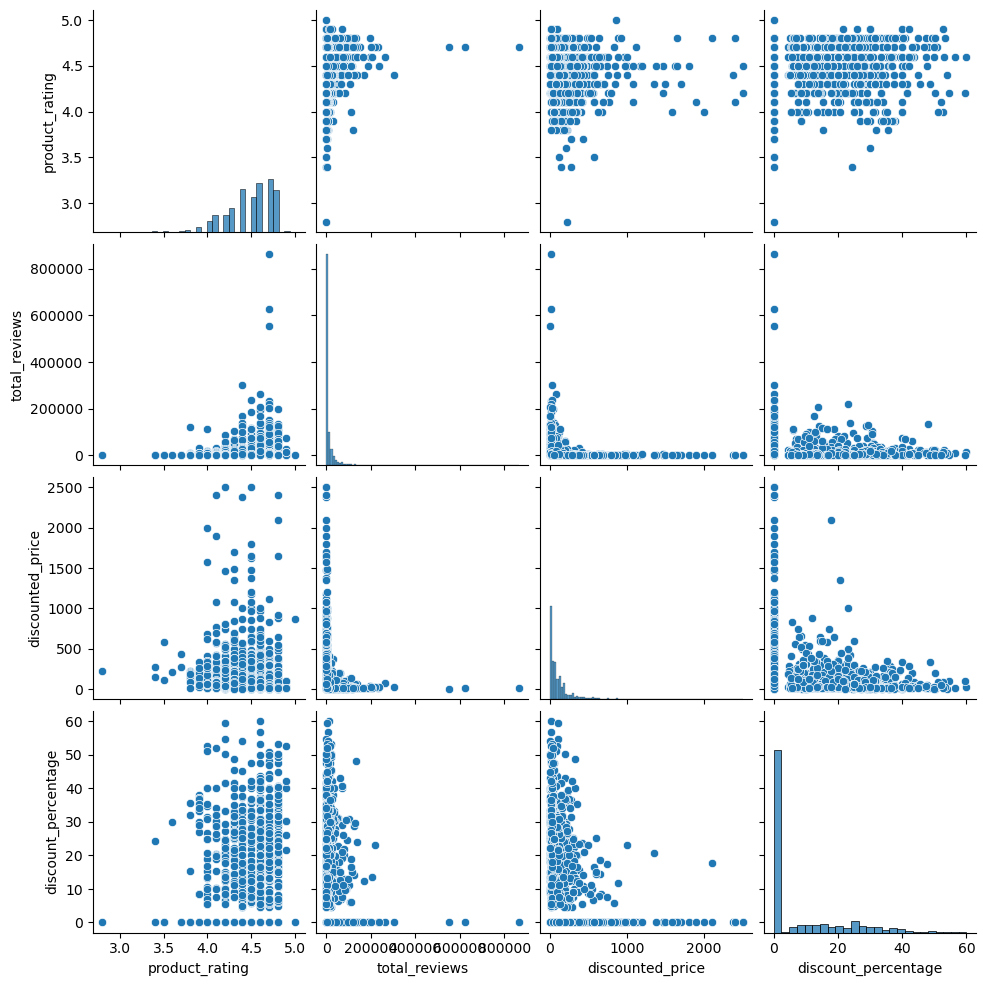

In [60]:
sns.pairplot(df[['product_rating','total_reviews','discounted_price','discount_percentage']])
plt.savefig("g26_pairplot.png")
plt.show()

### Interpretation:
The pairplot visualizes relationships between multiple numerical variables simultaneously. It helps in identifying correlations, trends, and clusters within the dataset. Strong relationships between certain variables can be observed, making it easier to understand overall data patterns.

## 34. Violin Plot (Rating Distribution)

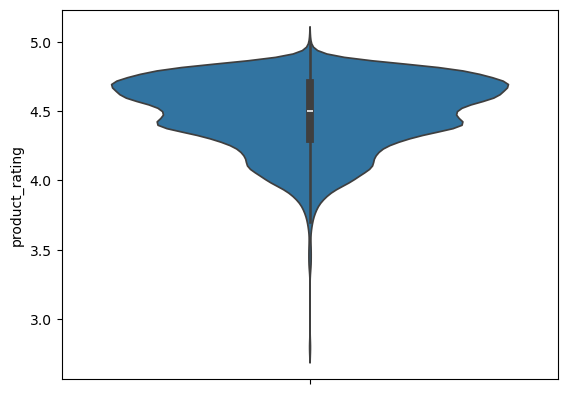

In [61]:
plt.figure()
sns.violinplot(y=df['product_rating'])
plt.savefig("g28_violin.png")
plt.show()

### Interpretation:
The violin plot provides a detailed view of rating distribution, combining boxplot and density information. It shows how ratings are spread and where they are most concentrated.

## 35. Strip Plot (Reviews vs Rating)

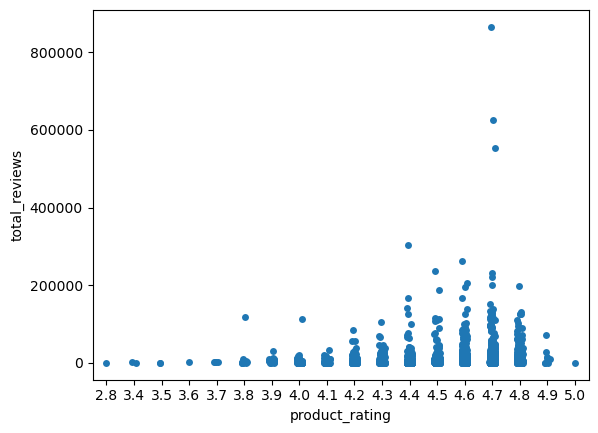

In [63]:
plt.figure()
sns.stripplot(x='product_rating', y='total_reviews', data=df)
plt.savefig("g30_strip.png")
plt.show()

### Interpretation:
The strip plot shows individual data points, helping visualize density and clustering. It reveals how reviews are distributed across different rating levels.